In [ ]:
from pathlib import Path
import requests
from tqdm import tqdm

Path("checkpoints").mkdir(exist_ok=True)

resp = requests.get(
    "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_base_plus.pt",
    stream=True,
)
total = int(resp.headers.get("content-length", 0))
with (
    open("checkpoints/sam2.1_hiera_base_plus.pt", "wb") as f,
    tqdm(
        total=total,
        unit="iB",
        unit_scale=True,
        unit_divisor=1024,
    ) as progress,
):
    for chunk in resp.iter_content(chunk_size=1024):
        progress.update(f.write(chunk))

100%|██████████| 309M/309M [02:46<00:00, 1.94MiB/s] 


[0.9782933  0.47636756 0.8636011 ]


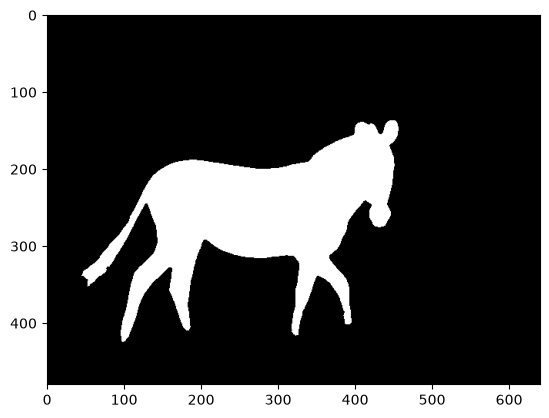

In [98]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator, SAM2ImagePredictor

model = build_sam2(
    "configs/sam2.1/sam2.1_hiera_b+.yaml",
    "checkpoints/sam2.1_hiera_base_plus.pt",
    device="mps",
)
predictor = SAM2ImagePredictor(model)

image = np.array(Image.open("zebras/001.jpeg").convert("RGB"))

predictor.set_image(image)
masks, scores, _ = predictor.predict(
    point_coords=np.array([[image.shape[1] / 2, image.shape[0] / 2]]),
    point_labels=np.array([1]),
    multimask_output=True,
)
print(scores)

mask = masks[np.argmax(scores)]
assert np.count_nonzero(((0 < mask) & (mask < 1))) == 0

plt.imshow(mask, cmap="grey")

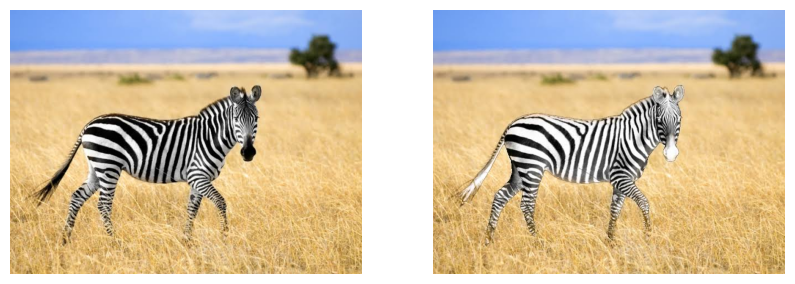

In [124]:
import colorsys

x = image.astype(np.float32) / 255
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        if mask[i, j]:
            h, l, s = colorsys.rgb_to_hls(*x[i, j])
            x[i, j] = colorsys.hls_to_rgb(h, 1.0 - l, s)

inv_image = (x * 255).astype(np.uint8)

n_rows = 1
n_cols = 2
fig, ax = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
ax[0, 0].axis("off")
ax[0, 0].imshow(image)
ax[0, 1].axis("off")
ax[0, 1].imshow(inv_image)

In [117]:
Image.fromarray(inv_image).save("zebras/001_inv.jpeg")